In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [2]:
# Load data from single file and detect models/datasets dynamically
def load_jsonl(filename, dataset_name):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    df = pd.DataFrame(data)
    df['dataset'] = dataset_name
    return df

# Load data from both files
df_maple = load_jsonl('maple-recursive-eiffel/res.jsonl', 'Maple')
df_jml = load_jsonl('buggy-java-jml-eiffel/res.jsonl', 'Jml')

print(f"Records loaded from maple-recursive-eiffel: {df_maple.shape[0]}")
print(f"Records loaded from buggy-java-jml-eiffel: {df_jml.shape[0]}")

# Combine both dataframes
df_all_raw = pd.concat([df_maple, df_jml], ignore_index=True)

print(f"Total records loaded: {df_all_raw.shape[0]}")

# Detect unique models and datasets
unique_models = sorted(df_all_raw['model'].unique())
unique_datasets = sorted(df_all_raw['dataset'].unique())

print(f"Models found: {unique_models}")
print(f"Datasets found: {unique_datasets}")

# Combine class_name and feature_name into a single identifier column
df_all_raw['class_feature'] = df_all_raw['class_name'] + '.' + df_all_raw['feature_name']
# Drop the original separate columns
df_all_raw.drop(columns=['class_name', 'feature_name'], inplace=True)

# Extract AI request times and verification times from interactions
def extract_ai_times(df):
    """Extract total AI request time and verification time from interactions array"""
    ai_request_times = []
    verification_times = []
    
    for idx, row in df.iterrows():
        interactions = row.get('interactions', [])
        if isinstance(interactions, list):
            total_ai_time = 0.0
            total_verification_time = 0.0
            for interaction in interactions:
                if isinstance(interaction, dict):
                    total_ai_time += interaction.get('ai_request_time_seconds', 0.0) or 0.0
                    total_verification_time += interaction.get('verification_time_seconds', 0.0) or 0.0
            ai_request_times.append(total_ai_time)
            verification_times.append(total_verification_time)
        else:
            ai_request_times.append(0.0)
            verification_times.append(0.0)
    
    df['total_ai_request_time_seconds'] = ai_request_times
    df['total_verification_time_seconds'] = verification_times
    return df

# Extract times for all data
df_all = extract_ai_times(df_all_raw)

df_all['final_status'].head()


Records loaded from maple-recursive-eiffel: 52
Records loaded from buggy-java-jml-eiffel: 3
Total records loaded: 55
Models found: ['claude-sonnet-4-5', 'gpt-4.1-nano']
Datasets found: ['Jml', 'Maple']


0    Verification passed after 1 LLM interaction(s)
1    Verification passed after 1 LLM interaction(s)
2                          Max retries (10) reached
3    Verification passed after 6 LLM interaction(s)
4                          Max retries (10) reached
Name: final_status, dtype: object

In [3]:
# Show failing examples by dataset and model
print("Failing examples by dataset and model:")
for dataset in sorted(df_all['dataset'].unique()):
    for model in unique_models:
        df_subset = df_all[(df_all['dataset'] == dataset) & (df_all['model'] == model)]
        failures = df_subset[df_subset['success'] == False]
        if len(failures) > 0:
            print(f"\n{dataset} - {model}: {len(failures)} failures")
            display(failures[['class_feature', 'llm_interactions', 'success', 'total_elapsed_time_seconds', 'final_status']].head())

Failing examples by dataset and model:

Jml - gpt-4.1-nano: 2 failures


,class_feature,llm_interactions,success,total_elapsed_time_seconds,final_status
53,LCM_10.lcm,10,False,242.147709,Max retries (10) reached
54,LCM_11.div,10,False,87.660853,Max retries (10) reached



Maple - gpt-4.1-nano: 6 failures


,class_feature,llm_interactions,success,total_elapsed_time_seconds,final_status
2,MAPLE_RECURSIVE_CONSEQ_1.sum,10,False,67.994535,Max retries (10) reached
4,MAPLE_RECURSIVE_CONSEQ_3.sum,10,False,67.303895,Max retries (10) reached
9,MAPLE_RECURSIVE_INCREMENT_4.increment,10,False,53.668428,Max retries (10) reached
15,MAPLE_RECURSIVE_MIN_2_2.sum,10,False,62.153939,Max retries (10) reached
20,MAPLE_RECURSIVE_SUM_3_1.sum,10,False,52.590878,Max retries (10) reached


SUCCESS/FAILURE DISTRIBUTION PER MODEL AND DATASET


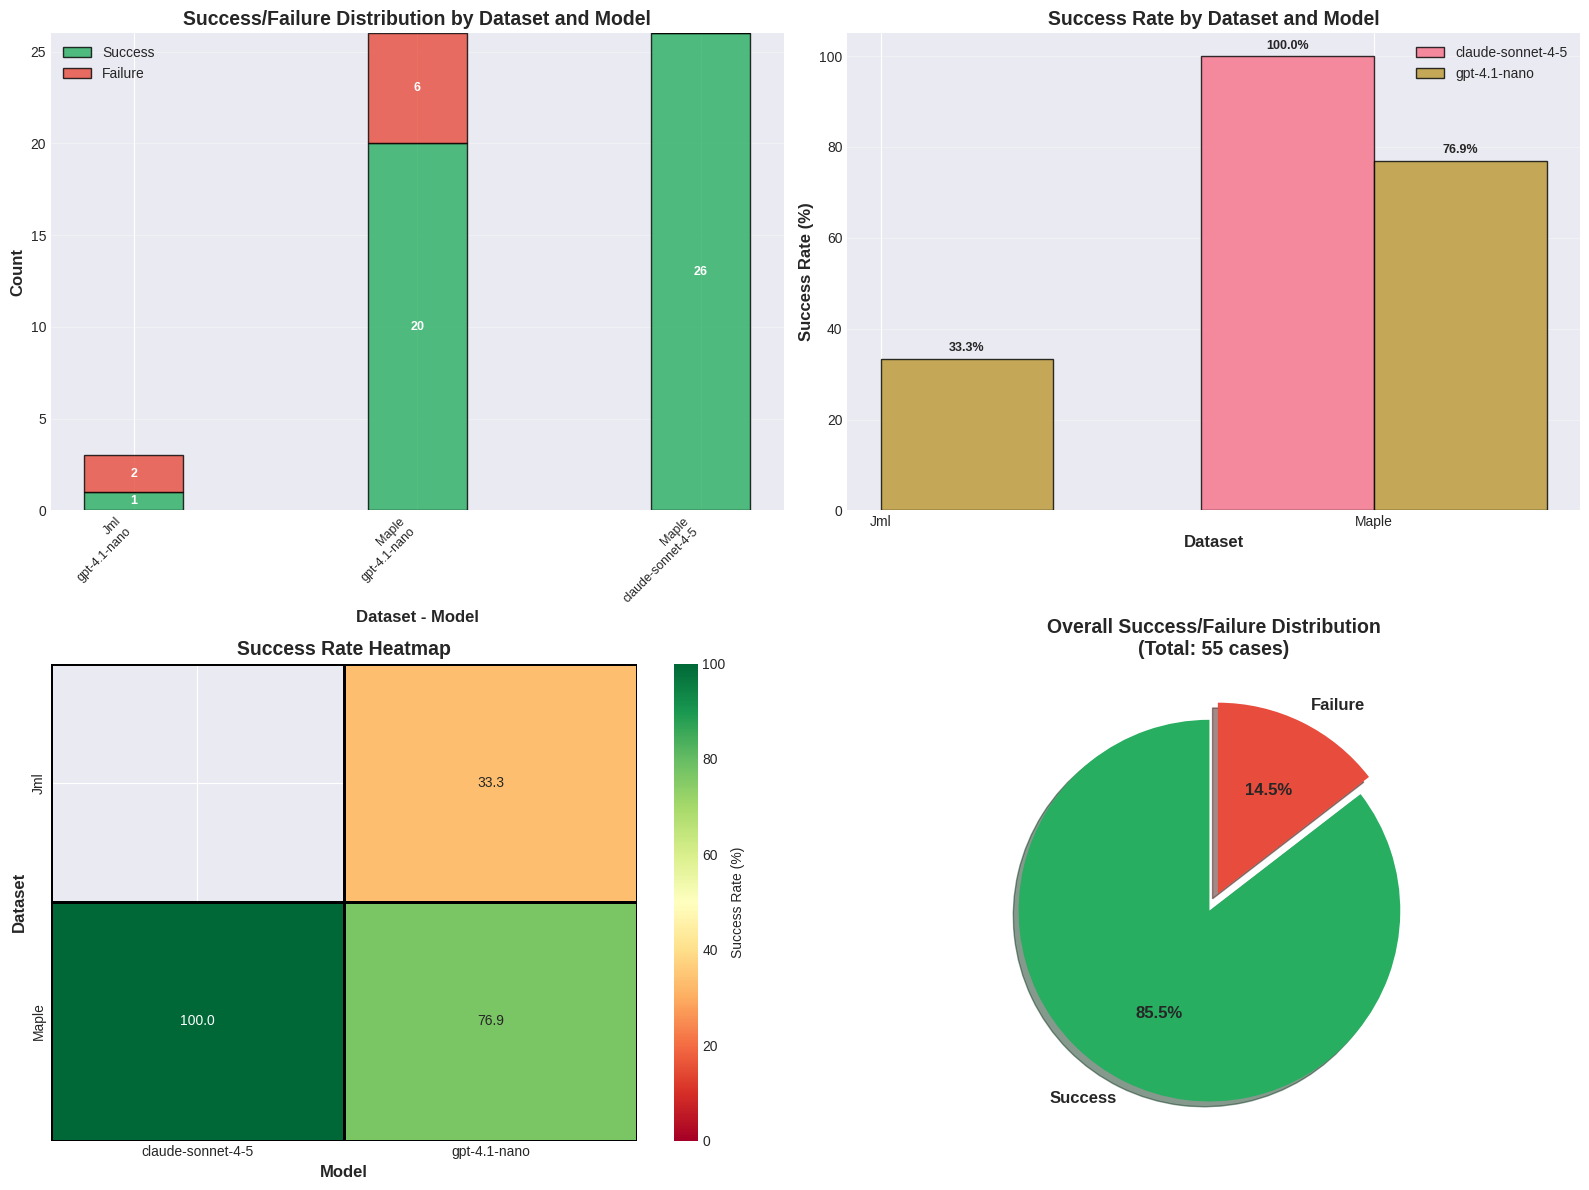


Summary Statistics:
Dataset             Model  Success  Failure  Total  Success Rate
    Jml      gpt-4.1-nano        1        2      3     33.333333
  Maple claude-sonnet-4-5       26        0     26    100.000000
  Maple      gpt-4.1-nano       20        6     26     76.923077


In [4]:
# Success/Failure Distribution Visualization
print("=" * 60)
print("SUCCESS/FAILURE DISTRIBUTION PER MODEL AND DATASET")
print("=" * 60)

# Create a summary dataframe
summary_data = []
for dataset in sorted(df_all['dataset'].unique()):
    for model in unique_models:
        df_subset = df_all[(df_all['dataset'] == dataset) & (df_all['model'] == model)]
        if len(df_subset) > 0:
            success_count = df_subset['success'].sum()
            failure_count = (~df_subset['success']).sum()
            total = len(df_subset)
            summary_data.append({
                'Dataset': dataset,
                'Model': model,
                'Success': success_count,
                'Failure': failure_count,
                'Total': total,
                'Success Rate': success_count / total * 100 if total > 0 else 0
            })

df_summary = pd.DataFrame(summary_data)

if len(df_summary) > 0:
    # Create figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Stacked bar chart: Success/Failure counts per model and dataset
    ax1 = axes[0, 0]
    datasets = df_summary['Dataset'].unique()
    models = df_summary['Model'].unique()
    
    x = np.arange(len(datasets))
    width = 0.35
    
    # Prepare data for grouped bars
    success_counts = []
    failure_counts = []
    labels = []
    
    for dataset in datasets:
        for model in models:
            row = df_summary[(df_summary['Dataset'] == dataset) & (df_summary['Model'] == model)]
            if len(row) > 0:
                success_counts.append(row.iloc[0]['Success'])
                failure_counts.append(row.iloc[0]['Failure'])
                labels.append(f"{dataset}\n{model}")
    
    x_pos = np.arange(len(labels))
    
    bars1 = ax1.bar(x_pos, success_counts, width, label='Success', color='#27ae60', alpha=0.8, edgecolor='black', linewidth=1)
    bars2 = ax1.bar(x_pos, failure_counts, width, bottom=success_counts, label='Failure', color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1)
    
    ax1.set_xlabel('Dataset - Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax1.set_title('Success/Failure Distribution by Dataset and Model', fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (s, f) in enumerate(zip(success_counts, failure_counts)):
        if s > 0:
            ax1.text(i, s/2, str(int(s)), ha='center', va='center', fontweight='bold', fontsize=9, color='white')
        if f > 0:
            ax1.text(i, s + f/2, str(int(f)), ha='center', va='center', fontweight='bold', fontsize=9, color='white')
    
    # 2. Grouped bar chart: Success rates per model and dataset
    ax2 = axes[0, 1]
    pivot_success_rate = df_summary.pivot(index='Dataset', columns='Model', values='Success Rate')
    
    x = np.arange(len(pivot_success_rate.index))
    width = 0.35
    
    for i, model in enumerate(pivot_success_rate.columns):
        offset = (i - len(pivot_success_rate.columns)/2 + 0.5) * width
        bars = ax2.bar(x + offset, pivot_success_rate[model], width, label=model, alpha=0.8, edgecolor='black', linewidth=1)
        
        # Add value labels
        for j, (bar, val) in enumerate(zip(bars, pivot_success_rate[model])):
            if not np.isnan(val) and val > 0:
                ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                        f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax2.set_xlabel('Dataset', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Success Rate by Dataset and Model', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(pivot_success_rate.index)
    ax2.legend()
    ax2.set_ylim([0, 105])
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Heatmap: Success rates
    ax3 = axes[1, 0]
    pivot_heatmap = df_summary.pivot(index='Dataset', columns='Model', values='Success Rate')
    sns.heatmap(pivot_heatmap, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100,
                cbar_kws={'label': 'Success Rate (%)'}, ax=ax3, linewidths=1, linecolor='black')
    ax3.set_title('Success Rate Heatmap', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Dataset', fontsize=12, fontweight='bold')
    
    # 4. Pie chart: Overall success/failure distribution
    ax4 = axes[1, 1]
    total_success = df_summary['Success'].sum()
    total_failure = df_summary['Failure'].sum()
    
    sizes = [total_success, total_failure]
    labels_pie = ['Success', 'Failure']
    colors = ['#27ae60', '#e74c3c']
    explode = (0.05, 0.05)
    
    wedges, texts, autotexts = ax4.pie(sizes, explode=explode, labels=labels_pie, colors=colors,
                                        autopct='%1.1f%%', shadow=True, startangle=90,
                                        textprops={'fontsize': 12, 'fontweight': 'bold'})
    
    ax4.set_title(f'Overall Success/Failure Distribution\n(Total: {total_success + total_failure} cases)', 
                  fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print(df_summary.to_string(index=False))
else:
    print("No data available for visualization")



TIME COMPARISON: LLM ANSWER TIME VS VERIFICATION TIME


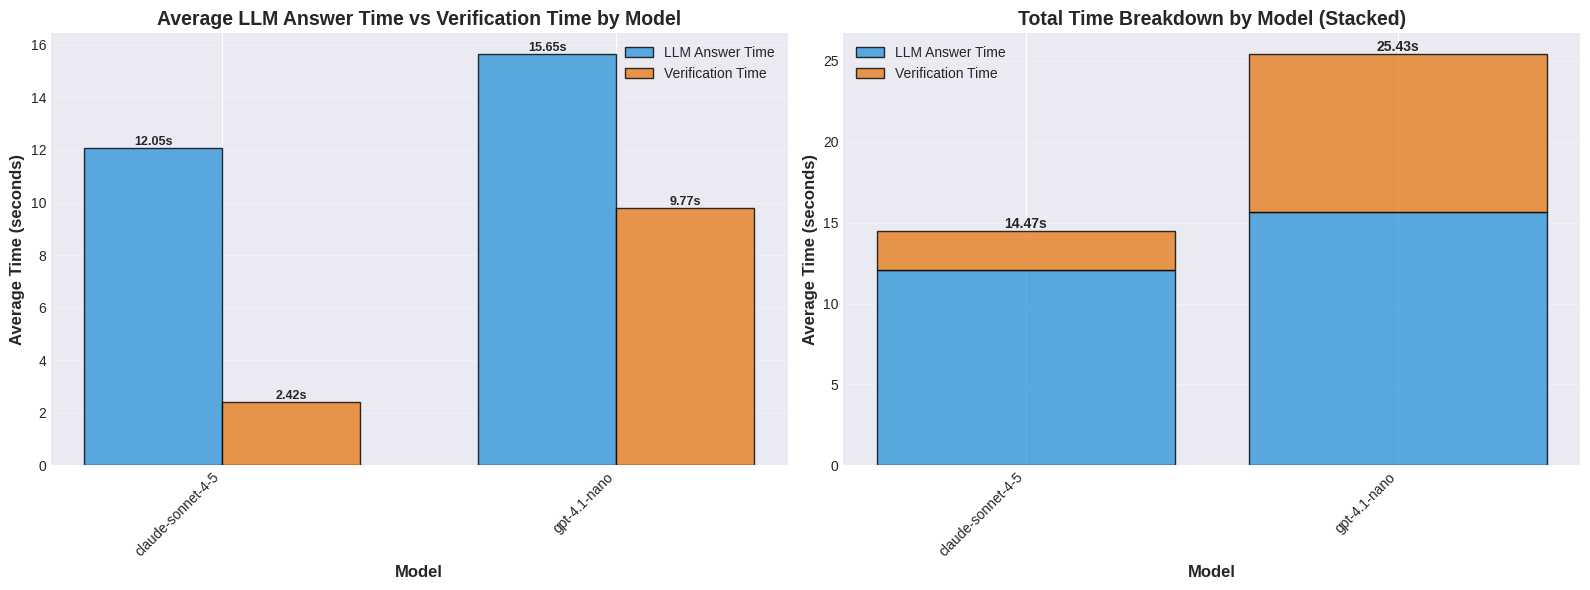


Time Comparison Statistics:
            Model  Avg AI Request Time (s)  Avg Verification Time (s)
claude-sonnet-4-5                12.054821                   2.415849
     gpt-4.1-nano                15.654226                   9.773889


In [5]:
# Time Comparison: LLM Answer Time vs Verification Time across Models
print("=" * 60)
print("TIME COMPARISON: LLM ANSWER TIME VS VERIFICATION TIME")
print("=" * 60)

# Calculate average times per model
time_comparison_data = []
for model in unique_models:
    df_model = df_all[df_all['model'] == model]
    if len(df_model) > 0:
        avg_ai_time = df_model['total_ai_request_time_seconds'].mean()
        avg_verification_time = df_model['total_verification_time_seconds'].mean()
        time_comparison_data.append({
            'Model': model,
            'Avg AI Request Time (s)': avg_ai_time,
            'Avg Verification Time (s)': avg_verification_time
        })

df_time_comparison = pd.DataFrame(time_comparison_data)

if len(df_time_comparison) > 0:
    # Create comparison figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Grouped bar chart comparing average times
    ax1 = axes[0]
    x = np.arange(len(df_time_comparison))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df_time_comparison['Avg AI Request Time (s)'], 
                    width, label='LLM Answer Time', color='#3498db', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    bars2 = ax1.bar(x + width/2, df_time_comparison['Avg Verification Time (s)'], 
                    width, label='Verification Time', color='#e67e22', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    
    ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Average Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_title('Average LLM Answer Time vs Verification Time by Model', 
                  fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_time_comparison['Model'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        height1 = bar1.get_height()
        height2 = bar2.get_height()
        ax1.text(bar1.get_x() + bar1.get_width()/2., height1,
                f'{height1:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax1.text(bar2.get_x() + bar2.get_width()/2., height2,
                f'{height2:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 2. Stacked bar chart showing total time breakdown
    ax2 = axes[1]
    x = np.arange(len(df_time_comparison))
    
    bars1 = ax2.bar(x, df_time_comparison['Avg AI Request Time (s)'], 
                    label='LLM Answer Time', color='#3498db', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    bars2 = ax2.bar(x, df_time_comparison['Avg Verification Time (s)'], 
                    bottom=df_time_comparison['Avg AI Request Time (s)'],
                    label='Verification Time', color='#e67e22', alpha=0.8, 
                    edgecolor='black', linewidth=1)
    
    ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Average Time (seconds)', fontsize=12, fontweight='bold')
    ax2.set_title('Total Time Breakdown by Model (Stacked)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_time_comparison['Model'], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add total time labels on top of stacked bars
    for i, row in df_time_comparison.iterrows():
        total = row['Avg AI Request Time (s)'] + row['Avg Verification Time (s)']
        ax2.text(i, total, f'{total:.2f}s', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print time comparison statistics
    print("\nTime Comparison Statistics:")
    print(df_time_comparison.to_string(index=False))
else:
    print("No data available for time comparison")

In [6]:
# Show interactions for the first failed example in Maple dataset
from IPython.display import HTML, display
import html

def format_interaction_html(interaction, interaction_num):
    """Format a single interaction as HTML"""
    html_str = f"""
    <div style="margin: 10px 0; padding: 15px; border-left: 4px solid #3498db; background-color: #f8f9fa;">
        <h4 style="margin-top: 0; color: #2c3e50;">Interaction {interaction.get('interaction_number', interaction_num)}</h4>
    """
    
    # Display prompt (if present)
    if 'prompt' in interaction and interaction['prompt']:
        prompt_text = html.escape(str(interaction['prompt']))
        # Preserve line breaks and indentation
        html_str += f"""
        <div style="margin: 10px 0;">
            <strong style="color: #3498db;">Prompt:</strong>
            <pre style="background-color: #e8f4f8; color: #2c3e50; padding: 15px; border: 1px solid #3498db; border-radius: 4px; 
                        white-space: pre-wrap; word-wrap: break-word; font-family: 'Consolas', 'Monaco', 'Courier New', monospace; 
                        font-size: 13px; line-height: 1.5; max-height: 500px; overflow-x: auto; overflow-y: auto;
                        tab-size: 4; -moz-tab-size: 4;">{prompt_text}</pre>
        </div>
        """
    
    # Display llm_message with proper formatting
    if 'llm_message' in interaction and interaction['llm_message']:
        llm_msg = html.escape(str(interaction['llm_message']))
        # Preserve line breaks and indentation
        html_str += f"""
        <div style="margin: 10px 0;">
            <strong style="color: #8e44ad;">LLM Message:</strong>
            <pre style="background-color: #2d2d2d; color: #f8f8f2; padding: 15px; border: 1px solid #555; border-radius: 4px; 
                        white-space: pre; font-family: 'Consolas', 'Monaco', 'Courier New', monospace; 
                        font-size: 13px; line-height: 1.5; max-height: 500px; overflow-x: auto; overflow-y: auto;
                        tab-size: 4; -moz-tab-size: 4;">{llm_msg}</pre>
        </div>
        """
    
    # 1. Display error message BEFORE (if present)
    error_message_before = None
    if 'error_message_before' in interaction and interaction['error_message_before']:
        error_message_before = interaction['error_message_before']
    elif 'verification_error_before' in interaction and interaction['verification_error_before']:
        error_message_before = interaction['verification_error_before']
    elif 'before_verification_error' in interaction and interaction['before_verification_error']:
        error_message_before = interaction['before_verification_error']
    
    if error_message_before:
        error_before = html.escape(str(error_message_before))
        error_before = error_before.replace('\n', '<br>')
        html_str += f"""
        <div style="margin: 10px 0;">
            <strong style="color: #e67e22;">Error Message (Before Code Change):</strong>
            <pre style="background-color: #fff3cd; padding: 10px; border: 1px solid #ffc107; border-radius: 4px; 
                        white-space: pre-wrap; word-wrap: break-word; font-family: 'Courier New', monospace; 
                        font-size: 12px; max-height: 400px; overflow-y: auto;">{error_before}</pre>
        </div>
        """
    
    # 2. Display code changes if present in the interaction object
    has_code_change = False
    code_change_html = """
        <div style="margin: 10px 0;">
            <strong style="color: #27ae60;">Code Change:</strong>
            <div style="margin-left: 20px;">
    """
    
    # 2a. Code BEFORE
    if 'before_code' in interaction and interaction['before_code']:
        has_code_change = True
        before = html.escape(str(interaction['before_code']))
        code_change_html += f"""
            <div style="margin: 10px 0;">
                <strong style="color: #c0392b;">Before:</strong>
                <pre style="background-color: #ffe6e6; padding: 12px; border: 1px solid #e74c3c; border-radius: 4px; 
                            white-space: pre; font-family: 'Consolas', 'Monaco', 'Courier New', monospace;
                            font-size: 12px; line-height: 1.4; max-height: 400px; overflow-y: auto;
                            tab-size: 4; -moz-tab-size: 4;">{before}</pre>
            </div>
        """
    
    # 2b. Code AFTER
    if 'after_code' in interaction and interaction['after_code']:
        has_code_change = True
        after = html.escape(str(interaction['after_code']))
        code_change_html += f"""
            <div style="margin: 10px 0;">
                <strong style="color: #27ae60;">After:</strong>
                <pre style="background-color: #e6ffe6; padding: 12px; border: 1px solid #27ae60; border-radius: 4px; 
                            white-space: pre; font-family: 'Consolas', 'Monaco', 'Courier New', monospace;
                            font-size: 12px; line-height: 1.4; max-height: 400px; overflow-y: auto;
                            tab-size: 4; -moz-tab-size: 4;">{after}</pre>
            </div>
        """
    
    if has_code_change:
        code_change_html += "</div></div>"
        html_str += code_change_html
    
    # 3. Display final error message (AFTER code change)
    if 'error_message' in interaction and interaction['error_message']:
        error_msg = html.escape(str(interaction['error_message']))
        # Preserve line breaks in error message
        error_msg = error_msg.replace('\n', '<br>')
        html_str += f"""
        <div style="margin: 10px 0;">
            <strong style="color: #e74c3c;">Error Message (After Code Change):</strong>
            <pre style="background-color: #fff; padding: 10px; border: 1px solid #ddd; border-radius: 4px; 
                        white-space: pre-wrap; word-wrap: break-word; font-family: 'Courier New', monospace; 
                        font-size: 12px; max-height: 400px; overflow-y: auto;">{error_msg}</pre>
        </div>
        """
    
    # Add any other fields (excluding already displayed ones)
    excluded_fields = ['error_message', 'error_message_before', 'interaction_number', 'llm_message', 
                      'before_code', 'after_code', 'verification_error_before', 
                      'verification_error_after', 'before_verification_error', 
                      'after_verification_error', 'prompt']
    other_fields = {k: v for k, v in interaction.items() if k not in excluded_fields}
    if other_fields:
        html_str += "<div style='margin: 10px 0;'><strong>Other Details:</strong><ul style='margin: 5px 0;'>"
        for key, value in other_fields.items():
            val_str = html.escape(str(value))
            # If it's a multiline string, format it as a code block
            if isinstance(value, str) and '\n' in val_str and len(val_str) > 50:
                html_str += f"""
                <li style="margin: 10px 0;">
                    <strong>{key}:</strong>
                    <pre style="background-color: #f5f5f5; padding: 8px; border-radius: 3px; 
                                white-space: pre-wrap; font-family: monospace; font-size: 11px; 
                                margin: 5px 0; max-height: 300px; overflow-y: auto;">{val_str}</pre>
                </li>
                """
            else:
                if isinstance(value, str) and '\n' in val_str:
                    val_str = val_str.replace('\n', '<br>')
                html_str += f"<li><strong>{key}:</strong> {val_str}</li>"
        html_str += "</ul></div>"
    
    html_str += "</div>"
    return html_str

# Get the first failed example from any dataset/model
all_failures = df_all[df_all['success'] == False]
if len(all_failures) > 0:
    failure = all_failures.iloc[-1]
    dataset = failure['dataset']
    model = failure['model']
    
    display(HTML(f"""
    <div style="padding: 20px; background-color: #ecf0f1; border-radius: 8px; margin-bottom: 20px;">
        <h1 style="color: #2c3e50; margin: 0;">FAILED EXAMPLE: {html.escape(dataset)} - {html.escape(model)}</h1>
        <p style="font-size: 16px; color: #7f8c8d; margin: 10px 0 0 0;">
            Class/Feature: <strong style="color: #3498db;">{html.escape(str(failure['class_feature']))}</strong><br>
            LLM Interactions: <strong style="color: #27ae60;">{failure['llm_interactions']}</strong><br>
            Total Elapsed Time: <strong>{failure['total_elapsed_time_seconds']:.2f}s</strong><br>
            AI Request Time: <strong>{failure['total_ai_request_time_seconds']:.2f}s</strong><br>
            Verification Time: <strong>{failure['total_verification_time_seconds']:.2f}s</strong><br>
            Success: <span style="color: #e74c3c; font-weight: bold;">{failure['success']}</span>
        </p>
    </div>
    """))

    interactions = failure.get('interactions', [])
    display(print(interactions))
    if isinstance(interactions, list) and len(interactions) > 0:
        display(HTML(f"<div style='margin-top: 20px;'><h2 style='color: #34495e;'>Interactions Details ({html.escape(dataset)} - {html.escape(model)}):</h2></div>"))
        for i, interaction in enumerate(interactions):
            display(HTML(format_interaction_html(interaction, i + 1)))
    else:
        display(HTML("<p>No interactions data available</p>"))
else:
    display(HTML("""
    <div style="padding: 20px; background-color: #d5f4e6; border-radius: 8px; color: #27ae60;">
        <h2>No failed examples found</h2>
    </div>
    """))



[{'interaction_number': 1, 'error_message_before': '\n    This is the counterexample AutoProof provides: \n    \n    Eiffel Compilation Manager\nVersion 24.05.0.0000 - linux-x86-64\n\nDegree 6: Examining System\nDegree 5: Parsing Classes\nDegree 4: Analyzing Inheritance\nDegree 3: Checking Types\nDegree 2: Generating Byte Code\nSystem Recompiled.\n======================================\nLCM_11.div\nVerification failed (0.97s).\n\nLine: 14. Postcondition res_mod may be violated.\nState: LCM_11.div =>\n\ta_n = 0\n\tResult = 0\nState: LCM_11.div:12 =>\n\ta_n = 0\n\tResult = 1\n', 'error_message': '\n    This is the counterexample AutoProof provides: \n    \n    Eiffel Compilation Manager\nVersion 24.05.0.0000 - linux-x86-64\n\nDegree 6: Examining System\nDegree 5: Parsing Classes\nDegree 4: Analyzing Inheritance\nDegree 3: Checking Types\nDegree 2: Generating Byte Code\nSystem Recompiled.\n======================================\nLCM_11.div\nVerification failed (0.71s).\n\nLine: 11. Postco

None